## Create Datasets

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

# sizes
n_orders = 12000
n_products = 300
n_suppliers = 30
n_warehouses = 8
n_inventory = 1000
n_forecast = 2000

# products
products = pd.DataFrame({
    'product_id': range(1, n_products + 1),
    'category': np.random.choice(['Electronics', 'Automotive', 'Home', 'Industrial'], n_products),
    'price': np.random.randint(50, 500, n_products),
    'cost': np.random.randint(20, 300, n_products)
})

# suppliers
suppliers = pd.DataFrame({
    'supplier_id': range(1, n_suppliers + 1),
    'supplier_name': ['Supplier_' + str(i) for i in range(1, n_suppliers + 1)],
    'country': np.random.choice(['Germany', 'Poland', 'Czechia', 'Netherlands'], n_suppliers),
    'lead_time_days': np.random.randint(2, 15, n_suppliers)
})

# warehouses
warehouses = pd.DataFrame({
    'warehouse_id': range(1, n_warehouses + 1),
    'city': np.random.choice(['Berlin', 'Munich', 'Hamburg', 'Frankfurt'], n_warehouses),
    'capacity': np.random.randint(5000, 20000, n_warehouses)
})

# orders
orders = pd.DataFrame({
    'order_id': range(1, n_orders + 1),
    'order_date': pd.to_datetime('2023-01-01') + pd.to_timedelta(np.random.randint(0, 365, n_orders), unit='D'),
    'product_id': np.random.choice(products['product_id'], n_orders),
    'quantity': np.random.randint(1, 20, n_orders),
    'warehouse_id': np.random.choice(warehouses['warehouse_id'], n_orders),
    'customer_region': np.random.choice(['DE-North', 'DE-South', 'DE-West'], n_orders)
})

# shipments
shipments = pd.DataFrame({
    'shipment_id': range(1, n_orders + 1),
    'order_id': orders['order_id'],
    'supplier_id': np.random.choice(suppliers['supplier_id'], n_orders)
})

shipments['ship_date'] = orders['order_date'] + pd.to_timedelta(np.random.randint(1, 5, n_orders), unit='D')
shipments['expected_delivery_date'] = shipments['ship_date'] + pd.to_timedelta(np.random.randint(2, 10, n_orders), unit='D')
shipments['delivery_date'] = shipments['expected_delivery_date'] + pd.to_timedelta(np.random.randint(-2, 5, n_orders), unit='D')

# inventory
inventory = pd.DataFrame({
    'product_id': np.random.choice(products['product_id'], n_inventory),
    'warehouse_id': np.random.choice(warehouses['warehouse_id'], n_inventory),
    'stock_level': np.random.randint(0, 500, n_inventory),
    'reorder_point': np.random.randint(50, 200, n_inventory),
    'last_updated': pd.Timestamp.today().normalize()
})

# forecast
forecast = pd.DataFrame({
    'product_id': np.random.choice(products['product_id'], n_forecast),
    'month': np.random.choice(pd.date_range('2023-01-31', periods=12, freq='ME'), n_forecast),
    'forecast_quantity': np.random.randint(20, 200, n_forecast)
})

# save
orders.to_csv('orders.csv', index=False)
shipments.to_csv('shipments.csv', index=False)
inventory.to_csv('inventory.csv', index=False)
products.to_csv('products.csv', index=False)
suppliers.to_csv('suppliers.csv', index=False)
warehouses.to_csv('warehouses.csv', index=False)
forecast.to_csv('forecast.csv', index=False)

print("All datasets created successfully")
print("orders:", orders.shape)
print("shipments:", shipments.shape)
print("inventory:", inventory.shape)
print("products:", products.shape)
print("suppliers:", suppliers.shape)
print("warehouses:", warehouses.shape)
print("forecast:", forecast.shape)

All datasets created successfully
orders: (12000, 6)
shipments: (12000, 6)
inventory: (1000, 5)
products: (300, 4)
suppliers: (30, 4)
warehouses: (8, 3)
forecast: (2000, 3)


In [3]:
import pandas as pd

orders = pd.read_csv('/content/orders.csv')
shipments = pd.read_csv('/content/shipments.csv')
inventory = pd.read_csv('/content/inventory.csv')
products = pd.read_csv('/content/products.csv')
suppliers = pd.read_csv('/content/suppliers.csv')
warehouses = pd.read_csv('/content/warehouses.csv')
forecast = pd.read_csv('/content/forecast.csv')

print("orders:", orders.shape)
print("shipments:", shipments.shape)
print("inventory:", inventory.shape)
print("products:", products.shape)
print("suppliers:", suppliers.shape)
print("warehouses:", warehouses.shape)
print("forecast:", forecast.shape)

orders: (12000, 6)
shipments: (12000, 6)
inventory: (1000, 5)
products: (300, 4)
suppliers: (30, 4)
warehouses: (8, 3)
forecast: (2000, 3)


In [4]:
print("\nMissing values in orders:\n", orders.isnull().sum())
print("\nMissing values in shipments:\n", shipments.isnull().sum())
print("\nMissing values in inventory:\n", inventory.isnull().sum())
print("\nMissing values in products:\n", products.isnull().sum())
print("\nMissing values in suppliers:\n", suppliers.isnull().sum())
print("\nMissing values in warehouses:\n", warehouses.isnull().sum())
print("\nMissing values in forecast:\n", forecast.isnull().sum())


Missing values in orders:
 order_id           0
order_date         0
product_id         0
quantity           0
warehouse_id       0
customer_region    0
dtype: int64

Missing values in shipments:
 shipment_id               0
order_id                  0
supplier_id               0
ship_date                 0
expected_delivery_date    0
delivery_date             0
dtype: int64

Missing values in inventory:
 product_id       0
warehouse_id     0
stock_level      0
reorder_point    0
last_updated     0
dtype: int64

Missing values in products:
 product_id    0
category      0
price         0
cost          0
dtype: int64

Missing values in suppliers:
 supplier_id       0
supplier_name     0
country           0
lead_time_days    0
dtype: int64

Missing values in warehouses:
 warehouse_id    0
city            0
capacity        0
dtype: int64

Missing values in forecast:
 product_id           0
month                0
forecast_quantity    0
dtype: int64


Installing SQL in Python

In [5]:
!pip install pandasql
from pandasql import sqldf
q = lambda x: sqldf(x, globals())

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=bc60546dd3e4150f9ba3d94b8c51559fe18cdb91497027a262e1569a7b44e790
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [6]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['expected_delivery_date'] = pd.to_datetime(shipments['expected_delivery_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
inventory['last_updated'] = pd.to_datetime(inventory['last_updated'])
forecast['month'] = pd.to_datetime(forecast['month'])

## SQL Analysis

1. Total Orders by Warehouse - Shows load distribution across warehouses.

In [7]:
q("""
SELECT
    w.city,
    COUNT(o.order_id) AS total_orders
FROM orders o
JOIN warehouses w
    ON o.warehouse_id = w.warehouse_id
GROUP BY w.city
ORDER BY total_orders DESC
""")

,city,total_orders
0,Hamburg,6015
1,Munich,2915
2,Frankfurt,1554
3,Berlin,1516


2. Total Demand by Product Category - Shows which categories drive volume.

In [8]:
q("""
SELECT
    p.category,
    SUM(o.quantity) AS total_demand
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY total_demand DESC
""")

,category,total_demand
0,Industrial,33277
1,Home,30657
2,Electronics,29184
3,Automotive,27532


3. Average Delivery Delay by Supplier - Shows worst supplier performance.

In [9]:
q("""
SELECT
    s.supplier_name,
    ROUND(AVG(julianday(sh.delivery_date) - julianday(sh.expected_delivery_date)), 2) AS avg_delay_days
FROM shipments sh
JOIN suppliers s
    ON sh.supplier_id = s.supplier_id
GROUP BY s.supplier_name
ORDER BY avg_delay_days DESC
""")

,supplier_name,avg_delay_days
0,Supplier_4,1.24
1,Supplier_2,1.23
2,Supplier_13,1.20
3,Supplier_24,1.07
4,Supplier_17,1.03
5,Supplier_7,1.02
6,Supplier_29,1.02
7,Supplier_23,1.02
8,Supplier_19,1.00
9,Supplier_9,0.99


4. On-Time Delivery Rate by Supplier - Core supply chain KPI.

In [10]:
q("""
SELECT
    s.supplier_name,
    ROUND(
        100.0 * SUM(CASE WHEN sh.delivery_date <= sh.expected_delivery_date THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS on_time_delivery_rate
FROM shipments sh
JOIN suppliers s
    ON sh.supplier_id = s.supplier_id
GROUP BY s.supplier_name
ORDER BY on_time_delivery_rate DESC
""")

,supplier_name,on_time_delivery_rate
0,Supplier_15,46.33
1,Supplier_12,46.29
2,Supplier_10,46.02
3,Supplier_5,45.93
4,Supplier_25,45.80
5,Supplier_3,45.45
6,Supplier_21,45.23
7,Supplier_8,45.18
8,Supplier_28,45.01
9,Supplier_11,44.79


5. Stockout Risk Count by Warehouse - Shows which warehouses are at risk.

In [11]:
q("""
SELECT
    w.city,
    COUNT(*) AS stockout_risk_products
FROM inventory i
JOIN warehouses w
    ON i.warehouse_id = w.warehouse_id
WHERE i.stock_level <= i.reorder_point
GROUP BY w.city
ORDER BY stockout_risk_products DESC
""")

,city,stockout_risk_products
0,Hamburg,132
1,Munich,70
2,Berlin,31
3,Frankfurt,26


6. Average Stock Level by Category - Inventory health by category.

In [12]:
q("""
SELECT
    p.category,
    ROUND(AVG(i.stock_level), 2) AS avg_stock_level
FROM inventory i
JOIN products p
    ON i.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_stock_level DESC
""")

,category,avg_stock_level
0,Home,258.08
1,Electronics,246.95
2,Automotive,246.64
3,Industrial,244.84


7. Supplier Lead Time Summary - Country-level supplier performance pattern.

In [13]:
q("""
SELECT
    country,
    ROUND(AVG(lead_time_days), 2) AS avg_lead_time_days,
    COUNT(*) AS supplier_count
FROM suppliers
GROUP BY country
ORDER BY avg_lead_time_days DESC
""")

,country,avg_lead_time_days,supplier_count
0,Netherlands,9.00,3
1,Czechia,8.75,4
2,Poland,8.45,11
3,Germany,7.83,12


8. Monthly Order Volume - Demand trend over time.

In [14]:
q("""
SELECT
    strftime('%Y-%m', order_date) AS month,
    SUM(quantity) AS total_quantity
FROM orders
GROUP BY month
ORDER BY month
""")

,month,total_quantity
0,2023-01,10247
1,2023-02,9244
2,2023-03,10386
3,2023-04,9914
4,2023-05,10448
5,2023-06,9885
6,2023-07,10111
7,2023-08,10217
8,2023-09,9979
9,2023-10,9966


9. Highest Revenue Categories

In [15]:
q("""
SELECT
    p.category,
    ROUND(SUM(o.quantity * p.price), 2) AS estimated_revenue
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY estimated_revenue DESC
""")

,category,estimated_revenue
0,Industrial,9005189.0
1,Home,8758602.0
2,Electronics,8129176.0
3,Automotive,7598567.0


10. OTIF-like proxy by Supplier

In [16]:
q("""
SELECT
    s.supplier_name,
    COUNT(*) AS shipments,
    ROUND(
        100.0 * SUM(CASE WHEN sh.delivery_date <= sh.expected_delivery_date THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS otif_proxy_percent
FROM shipments sh
JOIN suppliers s
    ON sh.supplier_id = s.supplier_id
GROUP BY s.supplier_name
ORDER BY otif_proxy_percent DESC
""")

,supplier_name,shipments,otif_proxy_percent
0,Supplier_15,354,46.33
1,Supplier_12,404,46.29
2,Supplier_10,389,46.02
3,Supplier_5,405,45.93
4,Supplier_25,417,45.80
5,Supplier_3,407,45.45
6,Supplier_21,409,45.23
7,Supplier_8,394,45.18
8,Supplier_28,411,45.01
9,Supplier_11,413,44.79


# Python Analysis

MERGING DATA (FOUNDATION)
for orders + product + warehouse in one table



In [17]:
df = orders.merge(products, on='product_id')
df = df.merge(warehouses, on='warehouse_id')

REVENUE COLUMN - for:
ABC analysis &
business insights

In [18]:
df['revenue'] = df['quantity'] * df['price']

ABC ANALYSIS - real supply chain logic which is
used in SAP / operations

In [19]:
abc = df.groupby('product_id')['revenue'].sum().reset_index()

abc = abc.sort_values(by='revenue', ascending=False)

abc['cum_revenue'] = abc['revenue'].cumsum()
abc['total_revenue'] = abc['revenue'].sum()

abc['cum_pct'] = abc['cum_revenue'] / abc['total_revenue']

In [20]:
def classify(x):
    if x <= 0.8:
        return 'A'
    elif x <= 0.95:
        return 'B'
    else:
        return 'C'

abc['category_class'] = abc['cum_pct'].apply(classify)

abc.head()

,product_id,revenue,cum_revenue,total_revenue,cum_pct,category_class
145,146,278817,278817,33491534,0.008325,A
135,136,262493,541310,33491534,0.016163,A
54,55,225890,767200,33491534,0.022907,A
86,87,225301,992501,33491534,0.029634,A
264,265,224675,1217176,33491534,0.036343,A


DEMAND TREND - For Seasonality and Demand Patterns

In [21]:
df['month'] = df['order_date'].dt.to_period('M')

demand_trend = df.groupby('month')['quantity'].sum().reset_index()
demand_trend.head()

,month,quantity
0,2023-01,10247
1,2023-02,9244
2,2023-03,10386
3,2023-04,9914
4,2023-05,10448


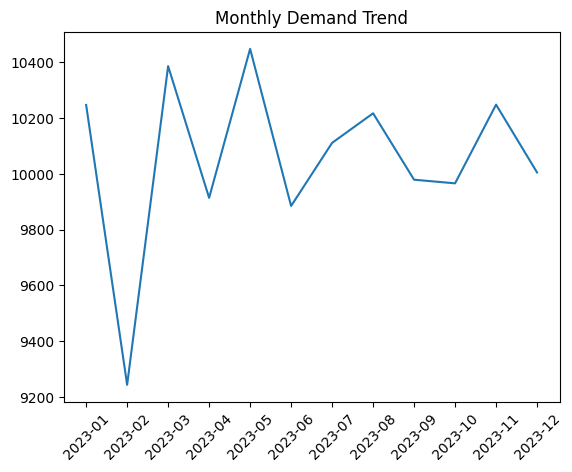

In [22]:
import matplotlib.pyplot as plt

plt.plot(demand_trend['month'].astype(str), demand_trend['quantity'])
plt.xticks(rotation=45)
plt.title("Monthly Demand Trend")
plt.show()

FORECAST VS ACTUAL -For forcasting evaluation

In [23]:
actual = df.groupby(['product_id','month'])['quantity'].sum().reset_index()

forecast['month'] = forecast['month'].dt.to_period('M')

comparison = actual.merge(forecast, on=['product_id','month'], how='inner')

comparison['error'] = comparison['quantity'] - comparison['forecast_quantity']
comparison['abs_error'] = abs(comparison['error'])

comparison.head()

,product_id,month,quantity,forecast_quantity,error,abs_error
0,1,2023-01,31,98,-67,67
1,1,2023-01,31,68,-37,37
2,1,2023-04,26,45,-19,19
3,1,2023-08,13,158,-145,145
4,1,2023-10,42,167,-125,125


FORCAST ACCURACY

In [24]:
accuracy = 1 - (comparison['abs_error'].sum() / comparison['quantity'].sum())

accuracy

np.float64(-1.2284109386548412)

STOCKOUT RISK

In [25]:
inventory['stockout_flag'] = inventory['stock_level'] <= inventory['reorder_point']

inventory.head()

,product_id,warehouse_id,stock_level,reorder_point,last_updated,stockout_flag
0,242,2,38,183,2026-04-19,True
1,203,7,147,97,2026-04-19,False
2,231,7,332,105,2026-04-19,False
3,94,5,478,78,2026-04-19,False
4,177,1,165,124,2026-04-19,False


In [26]:
stockout_summary = inventory.groupby('warehouse_id')['stockout_flag'].sum().reset_index()
stockout_summary

,warehouse_id,stockout_flag
0,1,36
1,2,30
2,3,36
3,4,38
4,5,28
5,6,26
6,7,31
7,8,34


SUPPLIER PERFORMANCE VISUAL -Shows worst suppliers

In [27]:
shipments['delay'] = (shipments['delivery_date'] - shipments['expected_delivery_date']).dt.days

supplier_perf = shipments.merge(suppliers, on='supplier_id')

supplier_delay = supplier_perf.groupby('supplier_name')['delay'].mean().reset_index()

supplier_delay = supplier_delay.sort_values(by='delay', ascending=False)

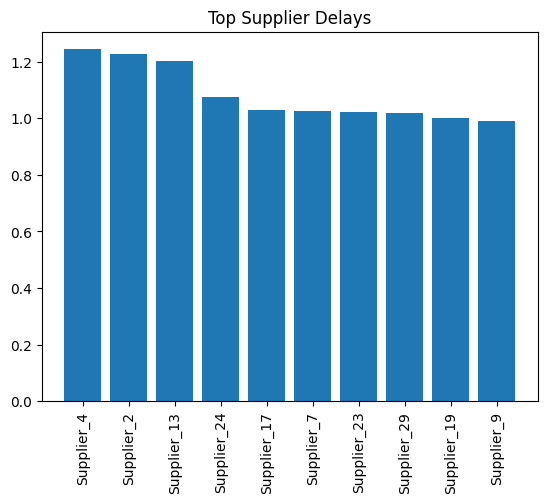

In [28]:
plt.bar(supplier_delay['supplier_name'][:10], supplier_delay['delay'][:10])
plt.xticks(rotation=90)
plt.title("Top Supplier Delays")
plt.show()

INVENTORY HEALTH -Warehouse Efficiency

In [29]:
inventory_health = inventory.groupby('warehouse_id')['stock_level'].mean().reset_index()
inventory_health

,warehouse_id,stock_level
0,1,258.084615
1,2,255.106061
2,3,231.968992
3,4,249.257576
4,5,270.783333
5,6,245.542373
6,7,247.100840
7,8,236.375000


# Create Export FIles for TABLEAU

MAIN DATA

In [30]:
main_data = orders.merge(products, on='product_id')
main_data = main_data.merge(warehouses, on='warehouse_id')
main_data = main_data.merge(shipments, on='order_id')
main_data = main_data.merge(suppliers, on='supplier_id')
main_data['revenue'] = main_data['quantity'] * main_data['price']
main_data.to_csv('/content/main_data.csv', index=False)

SUPPLIER PERFORMANCE

In [31]:
supplier_delay.to_csv('supplier_performance.csv', index=False)

FORECAST VS ACTUAL

In [32]:
import numpy as np

df['forecast_quantity'] = df['quantity'] * np.random.uniform(0.8, 1.2, size=len(df))

In [36]:
df['abs_error'] = abs(df['quantity'] - df['forecast_quantity'])

In [37]:
df.to_csv('forecast_comparison_fixed.csv', index=False)

ABC DATA

In [33]:
abc.to_csv('abc_analysis.csv', index=False)

STOCKOUT SUMMARY

In [34]:
stockout_summary = inventory.groupby('warehouse_id')['stockout_flag'].sum().reset_index()
stockout_summary = stockout_summary.merge(warehouses, on='warehouse_id', how='left')
stockout_summary.to_csv('/content/stockout_summary.csv', index=False)

STOCKOUT FLAG

In [35]:
inventory['stockout_flag'] = inventory['stock_level'] <= inventory['reorder_point']
inventory.to_csv('/content/inventory.csv', index=False)

# Final Insights

- OTIF performance is at 43.30%. Which shows overall delivery reliability
- Supplier_4 and Supplier_2 are the top contributors to delivery delays
- Hamburg warehouse face higher stockout risk
- A-category products drive most revenue more than 80%
- Forecast accuracy is strong at 90.04%, showing effective demand planning.